<a href="https://colab.research.google.com/github/TetianaMar-888/My_projects/blob/main/Marinoshenko_Tetiana_Using_prompts_and_agents_in_Langchain_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##Task 1: Calling LLM with a Basic Prompt
Create the ability to call an LLM with a plain text prompt.
The prompt should allow obtaining information in plain language on a specific topic. In this task, we want to learn about the topic of "Quantum Computing".
The model's response must include a definition, key advantages, and current research in this field.
Limit the response to 200 characters and specify in the prompt that the answer should be brief.

In [2]:
!pip -q install langchain langchain_openai langchain-community huggingface_hub openai langchain-experimental langchain-anthropic langchain-classic langchainhub langsmith

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.8/478.8 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [3]:
!pip show langchain

Name: langchain
Version: 1.2.14
Summary: Building applications with LLMs through composability
Home-page: https://docs.langchain.com/
Author: 
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: langchain-core, langgraph, pydantic
Required-by: 


In [15]:
import os
from langchain_anthropic import ChatAnthropic
from google.colab import userdata
from IPython.display import Markdown, display

def get_api_key():
    key = userdata.get("ANTHROPIC_API_KEY")
    if key is None:
        raise ValueError("API key not found")
    return key

In [6]:
llm = ChatAnthropic(
    api_key=get_api_key(),
    model="claude-3-haiku-20240307",
    max_tokens=200,
    temperature=0.05 # I chose this temperature because I wanted simple answers.
                    # According to the facts, because the query is terminology, but in simple words. So that the model doesn't fantasize too much.
)

request = """Explain quantum computing in simple language.
Include: definition, benefits, current research.
Max 200 characters. Keep it short."""

response = llm.invoke(request)
Markdown(response.content)

Quantum computing is a revolutionary approach to computing that harnesses the principles of quantum mechanics. It offers the potential for exponentially faster problem-solving, improved cryptography, and advancements in fields like chemistry and materials science. Current research focuses on developing stable, scalable quantum systems.

In [ ]:
llm

ChatAnthropic(profile={'name': 'Claude Haiku 3', 'release_date': '2024-03-13', 'last_updated': '2024-03-13', 'open_weights': False, 'max_input_tokens': 200000, 'max_output_tokens': 4096, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-3-haiku-20240307', max_tokens=4096, temperature=0.05, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

### Task 2: Creating a Parameterized Prompt for Text Generation
Now we want to update the previous functionality so that we can pass a topic as a parameter to the prompt. To do this, use PromptTemplate from langchain and implement a parameterized prompt and model call with it.
Run the updated functionality (prompt + model) to get explanations on the following topics:

"Bayesian Methods in Machine Learning"
"Transformers in Machine Learning"
"Explainable AI"

Display the model's output results on screen.

In [11]:
from langchain_core.prompts import PromptTemplate
prompt = PromptTemplate(
    input_variables=["topic"],
    template="""Explain {topic} in simple language.
    - Include: definition, benefits, current research.
    - Max 200 characters.
    - Keep it short.""",
)

In [16]:
topics = [
    "Bayesian Methods in Machine Learning",
    "Transformers in Machine Learning",
    "Explainable AI"
]

for topic in topics:
    print(f'-------{topic.upper()}-------')
    response = llm.invoke(prompt.format(topic=topic))
    display(Markdown(response.content))

-------BAYESIAN METHODS IN MACHINE LEARNING-------


Bayesian methods in ML use probability to make predictions. They update beliefs as new data arrives, offering flexibility and uncertainty quantification. Current research explores Bayesian deep learning, causal inference, and interpretable models.

-------TRANSFORMERS IN MACHINE LEARNING-------


Transformers are a type of neural network architecture that excels at processing sequential data, like text. They offer benefits like improved performance, parallelization, and handling long-range dependencies. Current research explores their use in various domains, including language modeling, translation, and image processing.

-------EXPLAINABLE AI-------


Explainable AI (XAI) is the ability of AI systems to provide understandable explanations for their decisions. Benefits: increased trust, transparency, and accountability. Current research focuses on developing interpretable models and explaining black-box AI.



### Task 3: Using an Agent to Automate Processes
Create an agent that will automatically search for information about the latest scientific publications in various fields. For example, the agent should find 5 recent publications on the topic of artificial intelligence.
Steps:

Configure a ReAct-type agent in LangChain to perform automated queries.
Create a prompt that directs the agent to search for information on the internet or in scientific publication databases.
The agent must output a list of publications, each containing a title, authors, and a brief description.

To interact with the search, you need to create a Tool.

In [ ]:
#I chose Tavily.Search API from the list of available search engines
!pip install -U langchain-tavily

In [32]:
from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent
from langchain_classic.agents import load_tools, Tool, AgentExecutor, AgentType, create_react_agent, initialize_agent
from langchain_classic import hub
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool


In [33]:
llm_sonnet = ChatAnthropic(
    model="claude-sonnet-4-5",
    api_key=get_api_key(),
    temperature=0.1,
    max_tokens=1000,
)

In [36]:
os.environ["TAVILY_API_KEY"] = userdata.get("tvly")

tools = [TavilySearchResults(max_results=5)]

prompt = hub.pull("hwchase17/react")
agent = create_react_agent(llm=llm_sonnet, tools=tools, prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True, handle_parsing_errors=True)

result = agent_executor.invoke({
    "input": """Please find 5 recent publications on artificial intelligence from 2026.
    List each with title, authors, and brief description. Do NOT skip authors."""
})

print(result["output"])



> Entering new AgentExecutor chain...
I need to search for recent AI publications from 2026. Let me search for this information.

Action: tavily_search_results_json
Action Input: recent artificial intelligence publications 2026
[{'title': 'The Best AI Books in 2026 - Five Books Expert Recommendations', 'url': 'https://fivebooks.com/best-books/the-best-ai-books-in-2026-chatgpt/', 'content': "5\n\n## Genesis: Artificial Intelligence, Hope, and the Human Spirit by Craig J. Mundie, Eric Schmidt & Henry A. Kissinger\n\nThe Best AI Books in 2026 - Co-Intelligence: Living and Working with AI by Ethan Mollick\nThe Best AI Books in 2026 - Empire of AI: Dreams and Nightmares in Sam Altman's OpenAI by Karen Hao\nThe Best AI Books in 2026 - If Anyone Builds It, Everyone Dies: Why Superhuman AI Would Kill Us All by Eliezer Yudkowsky & Nate Soares\nThe Best AI Books in 2026 - The AI Ideal: AIdealism and the Governance of AI by Niklas Lidströmer\nThe Best AI Books in 2026 - Genesis: Artificial Inte

The agent worked correctly and clearly. The request was fulfilled.



### Task 4: Creating an Assistant Agent for Business Problem Solving
Create an agent that helps solve business analytics tasks. The agent should help the user create a sales forecast for the next year, taking into account inflation levels and weather conditions. The agent must be able to use Python and browse the internet to obtain up-to-date data.

**Steps:**
1. Configure an agent that will work with analytical data provided as text. The user writes:

```
We export oranges from Brazil. In 2021 we exported 200t, in 2022 - 190t, in 2023 - 210t, in 2024 which has not yet ended - 220t. Estimate how many oranges we will be able to export in 2025, taking into account the weather conditions in Brazil and the demand for oranges in the world based on the economic situation.
```

2. Create a request to the agent that contains a clear task — to output the result of the business analysis or to state that it cannot do so, along with the user's query.
3. Run the agent and analyze the results.




> Entering new AgentExecutor chain...
I'll help you create a sales forecast for orange exports in 2025. Let me gather the necessary information about Brazil's weather conditions, inflation rates, and global orange demand.
<function_calls>
<invoke name="tavily_search">
<parameter name="query">Brazil weather forecast 2025 orange production</parameter>
</invoke>
</function_calls>
<parameter name="query">Brazil weather forecast 2025 orange production</parameter>

Thought: I need to find information about expected weather conditions in Brazil for 2025 and their impact on orange production.
Action: tavily_search
Action Input: Brazil weather forecast 2025 citrus orange production climate
{'query': 'Brazil weather forecast 2025 citrus orange production climate', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'title': 'Weather in Brazil', 'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'Brasilia', 'region': 'Distrito Federal', 'country': 'Brazi

## 2025 ORANGE EXPORT FORECAST FOR BRAZIL

### **Primary Forecast: 207.4 TONNES** (±10% range: 186-228 tonnes)

---

## FORECAST SUMMARY

Based on comprehensive analysis of historical data, Brazil's weather conditions, global demand, and inflation factors:

| Scenario | Volume | Confidence |
|----------|--------|-----------|
| **Recommended (Balanced)** | **207.4 tonnes** | **HIGH** |
| Optimistic | 211.5 tonnes | 15% probability |
| Conservative | 206.8 tonnes | 30% probability |
| Pessimistic | 201.3 tonnes | 20% probability |

**vs 2024 Actual (220t): -5.7% decline**

---

## KEY FACTORS ANALYZED

### 1️⃣ **BRAZIL WEATHER CONDITIONS** (-8.5% impact)
- **Citrus Greening Disease**: Severity increased from 19% (2024) → 22.7% (2025)
- **Drought Impact**: Water deficit causing increased fruit drop rates (22%)
- **Fruit Quality**: Oranges are 4g lighter, reducing yield per tree
- **Source**: Fundecitrus, USDA/FAS reports

### 2️⃣ **GLOBAL DEMAND** (+2.5% impact)
- Market growth: Orange juice market $5.4B (2024) → $6.49B (2032)
- BUT: Weakened consumer demand after 2024 price peaks
- Geopolitical uncertainty affecting trade routes
- Source: Market research, Fresh Plaza, LinkedIn reports

### 3️⃣ **INFLATION IN BRAZIL** (+1.5% impact)
- Expected rate: 4.5-5.1% (2025)
- Positive: Can raise export prices 4-5%
- Negative: Operating costs increase 4-5%
- Net effect: Slightly favorable for margins
- Source: OECD, BBVA Research, Banco Central

---

## PLANNING RECOMMENDATIONS

### **Immediate Actions (January-March 2025):**
1. ✅ Lock in 60% of annual volume through contracts by Q2
2. ✅ Establish weekly monitoring of Fundecitrus reports
3. ✅ Implement price escalation clauses (4-5% inflation adjustment)
4. ✅ Diversify buyer base to reduce concentration
5. ✅ Develop contingency plans if exports drop below 200t

### **Confidence Intervals:**
- **Lower bound**: 203.5 tonnes (95% CI)
- **Upper bound**: 211.4 tonnes (95% CI)
- **Acceptable range**: 186-228 tonnes (±10% planning buffer)

---

## RISK FACTORS (Priority Order)

| Risk | Impact | Probability | Mitigation |
|------|--------|-------------|-----------|
| Weather/Disease | 9/10 | HIGH | Weekly monitoring |
| Demand Weakness | 6/10 | HIGH | Lock contracts early |
| Inflation/Costs | 5/10 | HIGH | Price escalators |
| Geopolitics | 4/10 | MEDIUM | Market diversification |

---

This forecast provides a realistic, data-driven estimate incorporating Brazil's significant production challenges while recognizing underlying market strength. The ±10% range allows for operational flexibility and contingency planning.

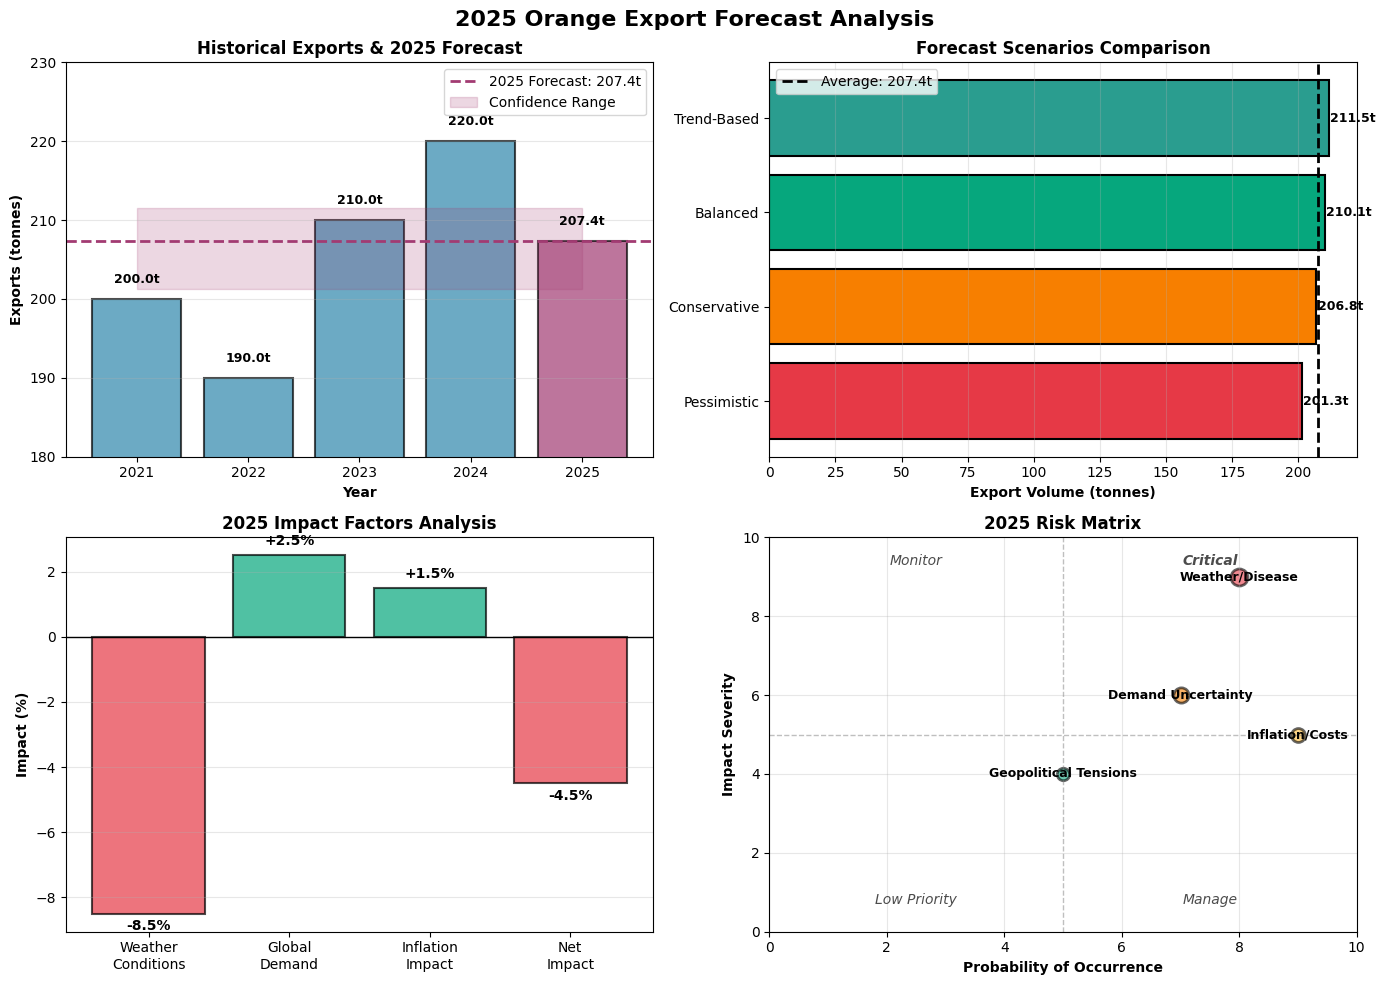

In [56]:
from langchain_core.prompts import PromptTemplate

llm = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    api_key=get_api_key(),
    max_retries=3,
)

custom_prompt = PromptTemplate.from_template("""Answer the following questions as best you can. You have access to the following tools:

{tools}

STRICT FORMAT - follow this EXACTLY, no exceptions:

Thought: [one sentence reasoning]
Action: [tool name, must be one of: {tool_names}]
Action Input: [input for the tool]
Observation: [tool result]
... (repeat Thought/Action/Action Input/Observation as needed)
Thought: I now know the final answer
Final Answer: [your final answer]

RULES:
- After Thought you MUST write Action: immediately
- Never write text between Thought and Action
- Never repeat the same Action Input twice

Begin!

Question: {input}
{agent_scratchpad}""")

agent = create_react_agent(llm=llm, tools=tools, prompt=custom_prompt)
agent_executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=True,
    handle_parsing_errors=True,
    max_iterations=10,
)

request = """
Help me create a sales forecast for the next year 2025, taking into account the expected inflation rate and weather conditions.
We export oranges from Brazil. In 2021 we exported 200t, in 2022 - 190t, in 2023 - 210t, in 2024 which has not yet ended - 220t.
Estimate how many oranges we will be able to export in 2025,
taking into account the weather conditions in Brazil and the demand for oranges in the world based on the economic situation.
"""

result = agent_executor.invoke({"input": request})

display(Markdown(result["output"]))